In [59]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_parquet('data.parquet')
print(len(df))
df = df.loc[df['play_type']=='run']
print(len(df))

365539
150189


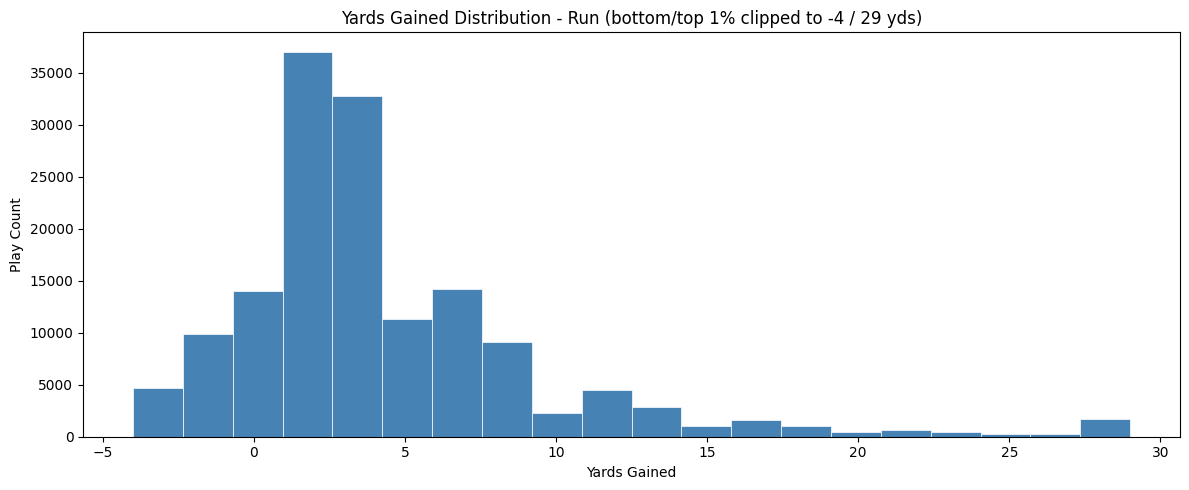

In [5]:
temp = df.copy()

low = temp['yards_gained'].quantile(0.01)
high = temp['yards_gained'].quantile(0.99)

clipped = temp['yards_gained'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards Gained')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards Gained Distribution - Run (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Distribution Selection

In [39]:
rush = df[
    (pbp["play_type"] == "run") &
    (pbp["yards_gained"].notna()) &
    (pbp["down"] != 'two_point_attempt')
].copy()

yards = rush["yards_gained"].values.astype(float)
print(f"Rush plays after filtering: {len(yards):,}")
print(f"  Mean:   {yards.mean():.2f} yds")
print(f"  Median: {np.median(yards):.2f} yds")
print(f"  Std:    {yards.std():.2f} yds")
print(f"  Min:    {yards.min():.0f} yds  Max: {yards.max():.0f} yds")

Rush plays after filtering: 149,926
  Mean:   4.37 yds
  Median: 3.00 yds
  Std:    6.38 yds
  Min:    -28 yds  Max: 99 yds


In [22]:
DISTRIBUTIONS = {
    "Normal":           stats.norm,
    "Skew-Normal":      stats.skewnorm,
    "Johnson SU":       stats.johnsonsu,
    "Gen. Normal":      stats.gennorm,
    "Laplace":          stats.laplace,
    "Skew-t":           stats.nct,
    "NIG":              stats.norminvgauss,
    "Gen. Hyperbolic":  stats.genhyperbolic,
    "Asym. Laplace":    stats.laplace_asymmetric,
}

In [23]:
def fit_distribution(dist, data):
    """Fit a scipy distribution and return params + diagnostics."""
    params = dist.fit(data)
    log_lik = np.sum(dist.logpdf(data, *params))
    k = len(params)
    n = len(data)
    aic = 2 * k - 2 * log_lik
    bic = k * np.log(n) - 2 * log_lik
    ks_stat, ks_p = stats.kstest(data, dist.cdf, args=params)
    return {
        "params": params,
        "log_lik": log_lik,
        "aic": aic,
        "bic": bic,
        "ks_stat": ks_stat,
        "ks_p": ks_p,
    }

results = {}
for name, dist in DISTRIBUTIONS.items():
    print(f"Fitting {name}...", end=" ")
    res = fit_distribution(dist, yards)
    results[name] = res
    print(f"AIC={res['aic']:.1f}  BIC={res['bic']:.1f}  KS={res['ks_stat']:.4f}")


Fitting Normal... AIC=981316.6  BIC=981336.5  KS=0.1908
AIC=916771.7  BIC=916801.4  KS=0.1724
AIC=865415.5  BIC=865455.2  KS=0.0677
AIC=881088.9  BIC=881118.7  KS=0.1696
Fitting Laplace... AIC=898536.3  BIC=898556.1  KS=0.1238
AIC=865566.6  BIC=865606.2  KS=0.0649
AIC=865532.3  BIC=865572.0  KS=0.0659
AIC=865250.6  BIC=865300.2  KS=0.0664
AIC=869919.9  BIC=869949.7  KS=0.0766


In [24]:
summary = pd.DataFrame({
    name: {
        "Log-Likelihood": f"{r['log_lik']:.1f}",
        "AIC":            f"{r['aic']:.1f}",
        "BIC":            f"{r['bic']:.1f}",
        "KS Statistic":   f"{r['ks_stat']:.4f}",
        "KS p-value":     f"{r['ks_p']:.4f}",
    }
    for name, r in results.items()
}).T

print("\n── Distribution Comparison ──────────────────────────────────────────")
print(summary.to_string())

best_aic = min(results, key=lambda n: results[n]["aic"])
best_bic = min(results, key=lambda n: results[n]["bic"])
best_ks  = min(results, key=lambda n: results[n]["ks_stat"])
print(f"\n  Best AIC: {best_aic}")
print(f"  Best BIC: {best_bic}")
print(f"  Best KS:  {best_ks}")


── Distribution Comparison ──────────────────────────────────────────
                Log-Likelihood       AIC       BIC KS Statistic KS p-value
Normal               -490656.3  981316.6  981336.5       0.1908     0.0000
Skew-Normal          -458382.8  916771.7  916801.4       0.1724     0.0000
Johnson SU           -432703.8  865415.5  865455.2       0.0677     0.0000
Gen. Normal          -440541.5  881088.9  881118.7       0.1696     0.0000
Laplace              -449266.2  898536.3  898556.1       0.1238     0.0000
Skew-t               -432779.3  865566.6  865606.2       0.0649     0.0000
NIG                  -432762.2  865532.3  865572.0       0.0659     0.0000
Gen. Hyperbolic      -432620.3  865250.6  865300.2       0.0664     0.0000
Asym. Laplace        -434957.0  869919.9  869949.7       0.0766     0.0000

  Best AIC: Gen. Hyperbolic
  Best BIC: Gen. Hyperbolic
  Best KS:  Skew-t


In [35]:
COLORS = {
    "Normal":       "#4e79a7",
    "Skew-Normal":  "#f28e2b",
    "Johnson SU":   "#e15759",
    "Gen. Normal":  "#76b7b2",
    "Laplace":      "#59a14f",
    "Skew-t":           "#e377c2",
    "NIG":              "#8c564b",
    "Gen. Hyperbolic":  "#bcbd22",
    "Asym. Laplace":    "#17becf",
}

Filtered out distributions that do not look reasonable


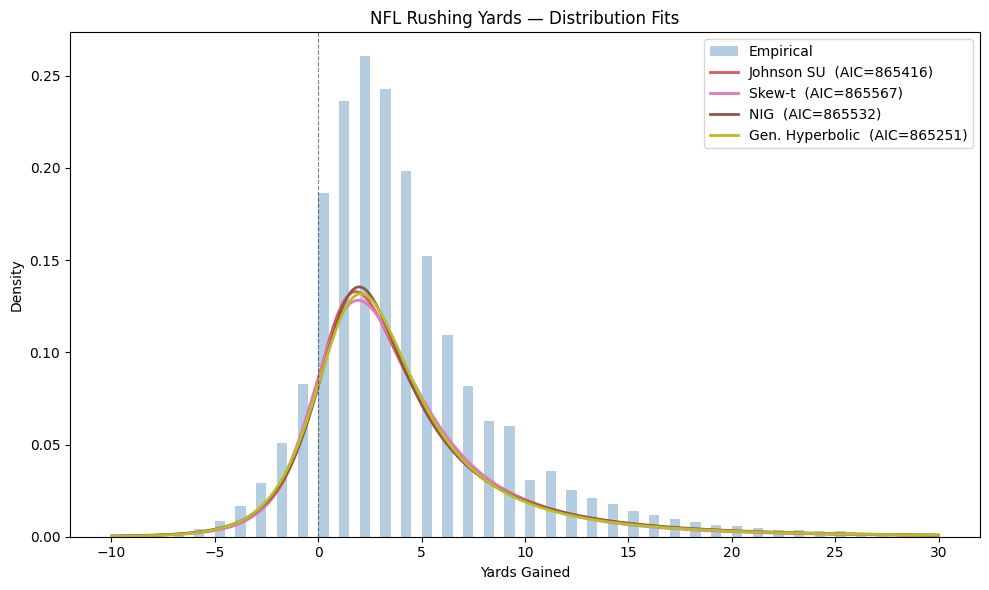

In [41]:
clip = (-10, 30)
yards_clipped = yards[(yards >= clip[0]) & (yards <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)
 
fig, ax = plt.subplots(figsize=(10, 6))
 
ax.hist(yards_clipped, bins=80, density=True,
        color="steelblue", alpha=0.4, label="Empirical")
print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    if(name not in ['Normal','Gen. Normal','Laplace','Skew-Normal','Asym. Laplace']):
        params = results[name]["params"]
        pdf_vals = dist.pdf(x_range, *params)
        ax.plot(x_range, pdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")
 
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL Rushing Yards — Distribution Fits")
ax.set_xlabel("Yards Gained")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

Filtered out distributions that do not look reasonable


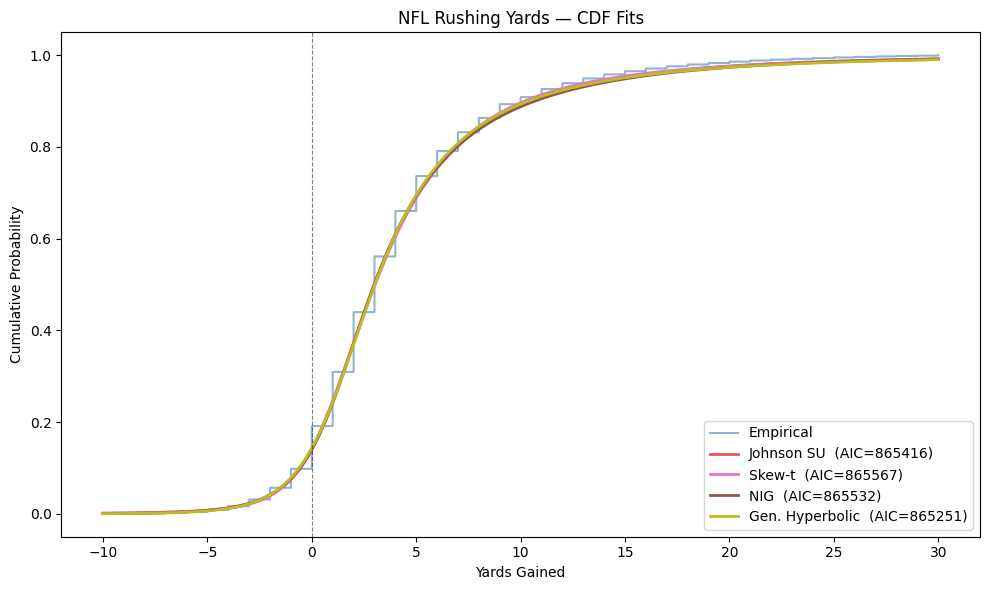

In [42]:
clip = (-10, 30)
yards_clipped = yards[(yards >= clip[0]) & (yards <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)

fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF
ecdf_x = np.sort(yards_clipped)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)
ax.step(ecdf_x, ecdf_y, color="steelblue", alpha=0.6, linewidth=1.5, label="Empirical")
print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    if name not in ['Normal', 'Gen. Normal', 'Laplace', 'Skew-Normal', 'Asym. Laplace']:
        params = results[name]["params"]
        cdf_vals = dist.cdf(x_range, *params)
        ax.plot(x_range, cdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL Rushing Yards — CDF Fits")
ax.set_xlabel("Yards Gained")
ax.set_ylabel("Cumulative Probability")
ax.legend()
plt.tight_layout()
plt.show()

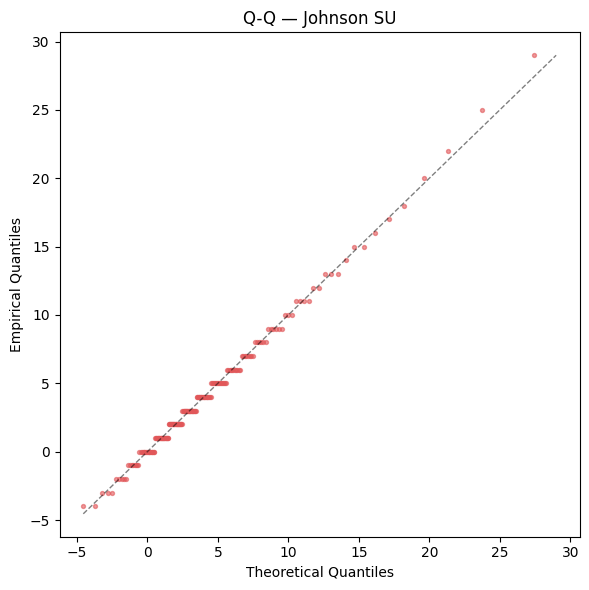

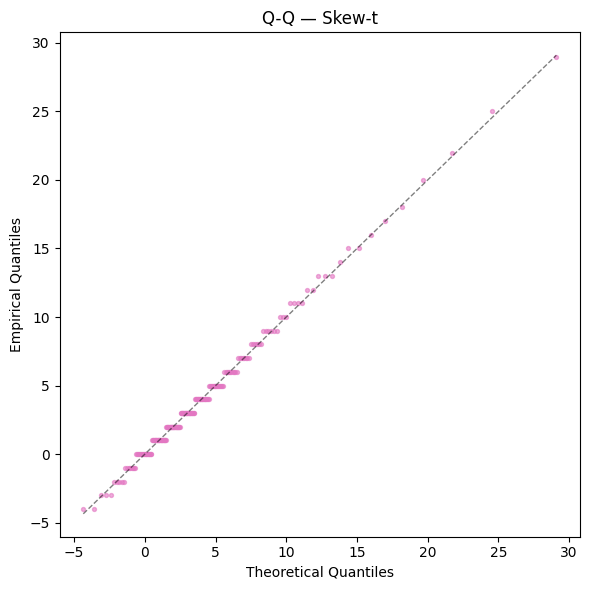

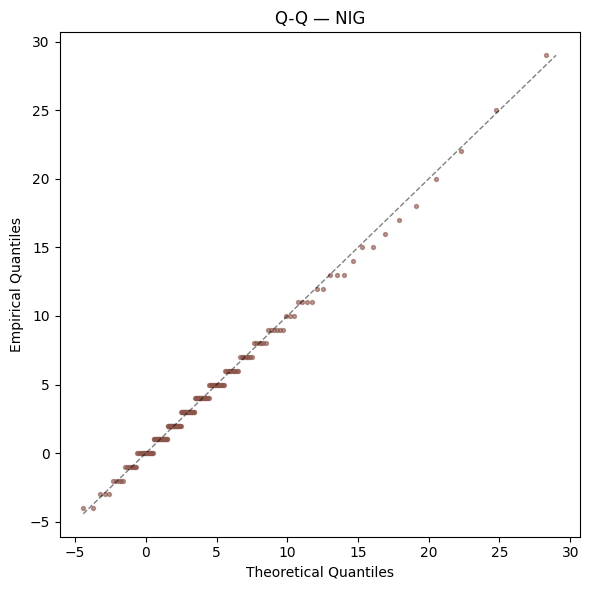

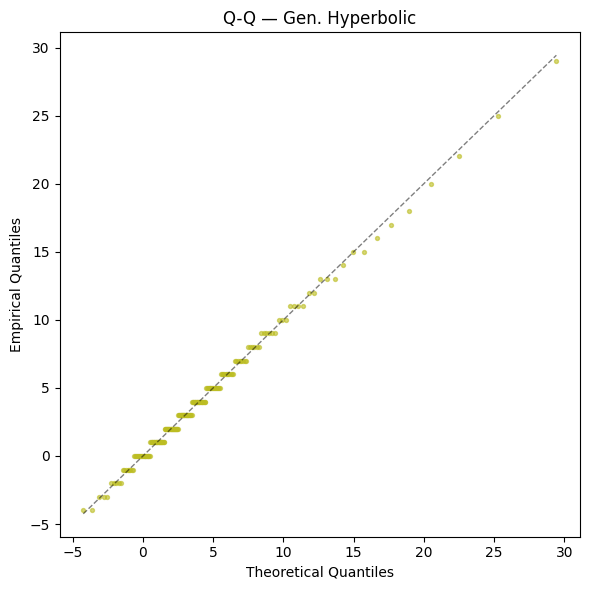

In [50]:
filtered = [name for name in DISTRIBUTIONS if name not in ['Normal', 'Gen. Normal', 'Laplace', 'Skew-Normal', 'Asym. Laplace']]
#filtered = [name for name in DISTRIBUTIONS]
percentiles = np.linspace(1, 99, 200)
empirical_q = np.percentile(yards, percentiles)

for name in filtered:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    dist = DISTRIBUTIONS[name]
    params = results[name]["params"]
    theoretical_q = dist.ppf(percentiles / 100, *params)

    ax.scatter(theoretical_q, empirical_q, color=COLORS[name], s=8, alpha=0.6)
    lims = [min(theoretical_q.min(), empirical_q.min()),
            max(theoretical_q.max(), empirical_q.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(f"Q-Q — {name}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")
    plt.tight_layout()
    plt.show()

## Model Code

In [60]:
idx = np.random.permutation(len(rush))
train_df = rush.iloc[idx[:int(.6*len(rush))]]
test_df = rush.iloc[idx[int(.6*len(rush)):int(.8*len(rush))]]
holdout_df = rush.iloc[idx[int(.8*len(rush)):]]

In [99]:
DISTRIBUTIONS = {
    "Normal":          stats.norm,
    "Skew-Normal":     stats.skewnorm,
    "Johnson SU":      stats.johnsonsu,
    "Gen. Normal":     stats.gennorm,
    "Laplace":         stats.laplace,
    "Skew-t":          stats.nct,
    "NIG":             stats.norminvgauss,
    "Gen. Hyperbolic": stats.genhyperbolic,
    "Asym. Laplace":   stats.laplace_asymmetric,
}

# Number of shape params (everything except loc and scale)
N_SHAPE_PARAMS = {
    "Normal":          0,
    "Skew-Normal":     1,
    "Johnson SU":      2,
    "Gen. Normal":     1,
    "Laplace":         0,
    "Skew-t":          2,
    "NIG":             2,
    "Gen. Hyperbolic": 3,
    "Asym. Laplace":   1,
}

def crps(dist, params_array, y):
    """
    Continuous Ranked Probability Score — lower is better.
    Approximated numerically via CDF integration.
    """
    scores = []
    x_grid = np.linspace(y.min() - 20, y.max() + 20, 300)
    for i, yi in enumerate(y):
        p = params_array[i]
        cdf_vals = dist.cdf(x_grid, *p)
        heaviside = (x_grid >= yi).astype(float)
        scores.append(np.trapz((cdf_vals - heaviside) ** 2, x_grid))
    return np.mean(scores)

def fit_distributional_model(train_df, test_df, yards_col, features, dist_name):
    assert dist_name in DISTRIBUTIONS, f"Unknown distribution: {dist_name}"
    dist    = DISTRIBUTIONS[dist_name]
    n_shape = N_SHAPE_PARAMS[dist_name]

    if len(features) == 0:
        X_train = np.ones((len(train_df), 1))
        X_test  = np.ones((len(test_df), 1))
    else:
        train_processed = pd.get_dummies(train_df[features], drop_first=True)
        test_processed  = pd.get_dummies(test_df[features],  drop_first=True)
        test_processed  = test_processed.reindex(columns=train_processed.columns, fill_value=0)
        X_train = train_processed.values.astype(float)
        X_test  = test_processed.values.astype(float)

    y_train = train_df[yards_col].values.astype(float)
    y_test  = test_df[yards_col].values.astype(float)

    n_features = X_train.shape[1]

    # ── Global MLE for shape params and initial guesses ──────────────────────
    global_params  = dist.fit(y_train)
    shape_params   = global_params[:n_shape]
    init_loc_bias  = global_params[-2]
    init_scale_bias = np.log(global_params[-1])

    # beta layout: [loc_coefs (n_features), loc_bias, log_scale_coefs (n_features), log_scale_bias]
    beta_init = np.zeros(2 * (n_features + 1))
    beta_init[n_features]              = init_loc_bias
    beta_init[2 * n_features + 1]      = init_scale_bias

    def neg_log_lik(beta):
        loc   = X_train @ beta[:n_features] + beta[n_features]
        scale = np.exp(X_train @ beta[n_features+1:2*n_features+1] + beta[2*n_features+1])
        ll = np.sum(dist.logpdf(y_train, *shape_params, loc, scale))
        return -ll if np.isfinite(ll) else 1e10
    result = minimize(neg_log_lik, beta_init, method="L-BFGS-B",
                      options={"maxiter": 1000, "ftol": 1e-9})
    beta_hat = result.x

    if len(features) == 0:
        feature_names = []
    else:
        feature_names = pd.get_dummies(train_df[features], drop_first=True).columns.tolist()

    beta_dict = {}
    for i, name in enumerate(feature_names):
        beta_dict[f"loc_{name}"] = beta_hat[i]
    beta_dict["loc_intercept"] = beta_hat[n_features]
    for i, name in enumerate(feature_names):
        beta_dict[f"log_scale_{name}"] = beta_hat[n_features + 1 + i]
    beta_dict["log_scale_intercept"] = beta_hat[2 * n_features + 1]

    model = {
        "dist":         dist,
        "dist_name":    dist_name,
        "beta":         beta_hat,
        "beta_dict":    beta_dict,
        "shape_params": shape_params,
        "n_shape":      n_shape,
        "n_features":   n_features,
        "features":     features,
        "yards_col":    yards_col,
    }

    _evaluate_model(model, X_test, y_test)
    return model


def _predict_params(model, X):
    beta       = model["beta"]
    n_features = model["n_features"]
    shapes     = model["shape_params"]

    loc   = X @ beta[:n_features] + beta[n_features]
    scale = np.exp(X @ beta[n_features+1:2*n_features+1] + beta[2*n_features+1])

    params_array = [tuple(shapes) + (loc[i], scale[i]) for i in range(len(X))]
    return params_array, loc


def _evaluate_model(model, X_test, y_test):
    dist = model["dist"]
    dist_name = model["dist_name"]

    params_array, loc_hat = _predict_params(model, X_test)

    # ── Log-likelihood ───────────────────────────────────────────────────────
    log_liks = [dist.logpdf(y_test[i], *params_array[i])
                for i in range(len(y_test))]
    mean_ll = np.mean(log_liks)

    # ── Mean predicted vs actual ─────────────────────────────────────────────
    true_means = np.array([dist.mean(*p) for p in params_array])
    mean_pred = np.mean(true_means)

    mean_actual = np.mean(y_test)
    mae = np.mean(np.abs(true_means - y_test))

    # ── Calibration: % of actuals inside predicted 50% interval ─────────────
    lower = np.array([dist.ppf(0.25, *p) for p in params_array])
    upper = np.array([dist.ppf(0.75, *p) for p in params_array])
    inside_50 = np.mean((y_test >= lower) & (y_test <= upper))

    lower90 = np.array([dist.ppf(0.05, *p) for p in params_array])
    upper90 = np.array([dist.ppf(0.95, *p) for p in params_array])
    inside_90 = np.mean((y_test >= lower90) & (y_test <= upper90))

    # ── KS statistic (average per-observation) ───────────────────────────────
    pit_vals = np.array([dist.cdf(y_test[i], *params_array[i])
                         for i in range(len(y_test))])
    ks_stat, ks_p = stats.kstest(pit_vals, "uniform")

    # ── CRPS ─────────────────────────────────────────────────────────────────
    crps_score = crps(dist, params_array, y_test)

    # ── Print summary ────────────────────────────────────────────────────────
    print(f"\n{'─' * 50}")
    print(f"  Distribution    : {dist_name}")
    print(f"  Test obs        : {len(y_test):,}")
    print(f"{'─' * 50}")
    print(f"  Mean log-lik    : {mean_ll:.4f}")
    print(f"  Mean actual yds : {mean_actual:.2f}")
    print(f"  Mean predicted  : {mean_pred:.2f}")
    print(f"  MAE             : {mae:.2f} yds")
    print(f"  Calibration 50% : {inside_50:.1%}  (target 50%)")
    print(f"  Calibration 90% : {inside_90:.1%}  (target 90%)")
    print(f"  KS stat (PIT)   : {ks_stat:.4f}  p={ks_p:.4f}")
    print(f"  CRPS            : {crps_score:.4f}  (lower is better)")
    print(f"{'─' * 50}\n")

## Fitting Models

In [100]:
model_a = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=["down"],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8824
  Mean actual yds : 4.37
  Mean predicted  : 4.33
  MAE             : 3.88 yds
  Calibration 50% : 45.8%  (target 50%)
  Calibration 90% : 89.4%  (target 90%)
  KS stat (PIT)   : 0.0661  p=0.0000
  CRPS            : 2.7719  (lower is better)
──────────────────────────────────────────────────



In [101]:
model_b = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=["down","off_rank","def_rank"],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8812
  Mean actual yds : 4.37
  Mean predicted  : 4.33
  MAE             : 3.87 yds
  Calibration 50% : 48.4%  (target 50%)
  Calibration 90% : 89.6%  (target 90%)
  KS stat (PIT)   : 0.0396  p=0.0000
  CRPS            : 2.7688  (lower is better)
──────────────────────────────────────────────────



In [102]:
model_c = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=["off_rank","def_rank"],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8819
  Mean actual yds : 4.37
  Mean predicted  : 4.32
  MAE             : 3.87 yds
  Calibration 50% : 49.0%  (target 50%)
  Calibration 90% : 89.6%  (target 90%)
  KS stat (PIT)   : 0.0421  p=0.0000
  CRPS            : 2.7702  (lower is better)
──────────────────────────────────────────────────



In [103]:
model_intercept = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=[],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8831
  Mean actual yds : 4.37
  Mean predicted  : 4.32
  MAE             : 3.88 yds
  Calibration 50% : 42.7%  (target 50%)
  Calibration 90% : 89.5%  (target 90%)
  KS stat (PIT)   : 0.0708  p=0.0000
  CRPS            : 2.7732  (lower is better)
──────────────────────────────────────────────────



## Evaluating a Model

In [114]:
model = model_a.copy()

In [123]:
def plot_model_vs_actual(model, test_df, variable, yards_col="yards_gained"):
    dist    = model["dist"]
    n_shape = model["n_shape"]
    features = model["features"]

    # ── Prepare features ─────────────────────────────────────────────────────
    if len(features) == 0:
        X_test = np.ones((len(test_df), 1))
    else:
        test_processed = pd.get_dummies(test_df[features], drop_first=True)
        train_cols = [k.replace("loc_", "", 1)
                      for k in model["beta_dict"]
                      if k.startswith("loc_") and k != "loc_intercept"]
        test_processed = test_processed.reindex(columns=train_cols, fill_value=0)
        X_test = test_processed.values.astype(float)

    params_array, _ = _predict_params(model, X_test)
    params_np = np.array(params_array)  # shape: (n_obs, n_shape + 2)

    shapes = [params_np[:, i] for i in range(n_shape)]
    loc    = params_np[:, -2]
    scale  = params_np[:, -1]

    true_means = dist.mean(*shapes, loc, scale)

    # ── Bucket the variable ───────────────────────────────────────────────────
    plot_df = test_df[[variable, yards_col]].copy().reset_index(drop=True)
    plot_df["predicted_mean"] = true_means
    plot_df["params_idx"]     = range(len(plot_df))
    plot_df = plot_df.dropna(subset=[variable, yards_col])

    continuous = plot_df[variable].nunique() > 20
    if continuous:
        plot_df["bucket"] = pd.cut(plot_df[variable].astype(float), bins=10).astype(str)
    else:
        try:
            plot_df["bucket"] = plot_df[variable].astype(float).astype(str)
        except (ValueError, TypeError):
            plot_df["bucket"] = plot_df[variable].astype(str)

    # ── Per-bucket actuals ────────────────────────────────────────────────────
    actual_grouped = plot_df.groupby("bucket").agg(
        actual_mean  = (yards_col, "mean"),
        actual_sigma = (yards_col, "std"),
        count        = (yards_col, "count"),
    ).reset_index()

    # ── Per-bucket model quantiles (vectorized) ───────────────────────────────
    def bucket_quantiles(grp):
        idxs   = grp["params_idx"].values
        ps     = params_np[idxs]
        sh     = [ps[:, i] for i in range(n_shape)]
        lc     = ps[:, -2]
        sc     = ps[:, -1]
        return pd.Series({
            "pred_mean": np.mean(dist.mean(*sh, lc, sc)),
            "q10":       np.mean(dist.ppf(0.10, *sh, lc, sc)),
            "q25":       np.mean(dist.ppf(0.25, *sh, lc, sc)),
            "q75":       np.mean(dist.ppf(0.75, *sh, lc, sc)),
            "q90":       np.mean(dist.ppf(0.90, *sh, lc, sc)),
        })

    model_grouped = plot_df.groupby("bucket").apply(bucket_quantiles).reset_index()
    merged = actual_grouped.merge(model_grouped, on="bucket")

    # ── Sort buckets ──────────────────────────────────────────────────────────
    if continuous:
        merged = merged.sort_values("bucket", key=lambda s: s.map(lambda v: float(v.split(",")[0].strip("([)"))))
    else:
        try:
            merged = merged.sort_values("bucket", key=lambda s: s.astype(float))
        except (ValueError, TypeError):
            merged = merged.sort_values("bucket")

    buckets = merged["bucket"].tolist()
    x       = np.arange(len(buckets))
    margin  = 1.645 * merged["actual_sigma"] / np.sqrt(merged["count"])

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    ax2.bar(x, merged["count"], width=0.6, alpha=0.15, color="gray")
    ax2.set_ylabel("Play Count")
    ax2.set_ylim(0, merged["count"].max() * 5)

    ax1.fill_between(x, merged["q10"], merged["q90"], alpha=0.15, color="orange", label="Model 10–90%")
    ax1.fill_between(x, merged["q25"], merged["q75"], alpha=0.25, color="orange", label="Model 25–75%")
    ax1.plot(x, merged["pred_mean"], color="orange", linewidth=2, marker="o", label="Model mean")

    ax1.fill_between(x, merged["actual_mean"] - margin,
                        merged["actual_mean"] + margin, alpha=0.2, color="green", label="Actual 90% CI")
    ax1.plot(x, merged["actual_mean"], color="green", linewidth=2, marker="o", label="Actual mean")

    overall_avg = plot_df[yards_col].mean()
    ax1.axhline(overall_avg, color="gray", linestyle="--", linewidth=1)
    ax1.annotate(f"Overall: {overall_avg:.1f}", xy=(x[-1], overall_avg),
                 xytext=(x[-1] - 0.1, overall_avg + 0.2), fontsize=8, ha="right", color="gray")

    ax1.set_xticks(x)
    ax1.set_xticklabels(buckets, rotation=45, ha="right")
    ax1.set_xlabel(variable)
    ax1.set_ylabel("Yards Gained")
    ax1.legend(loc="upper left", fontsize=8)
    plt.title(f"Model vs Actual — {variable}")
    plt.tight_layout()
    plt.show()

In [146]:
model = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=["down","off_rank","def_rank","goal_to_go","ydstogo","posteam_type","run_location","run_gap","shotgun"],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8415
  Mean actual yds : 4.37
  Mean predicted  : 4.41
  MAE             : 3.79 yds
  Calibration 50% : 50.4%  (target 50%)
  Calibration 90% : 90.2%  (target 90%)
  KS stat (PIT)   : 0.0188  p=0.0000
  CRPS            : 2.7044  (lower is better)
──────────────────────────────────────────────────



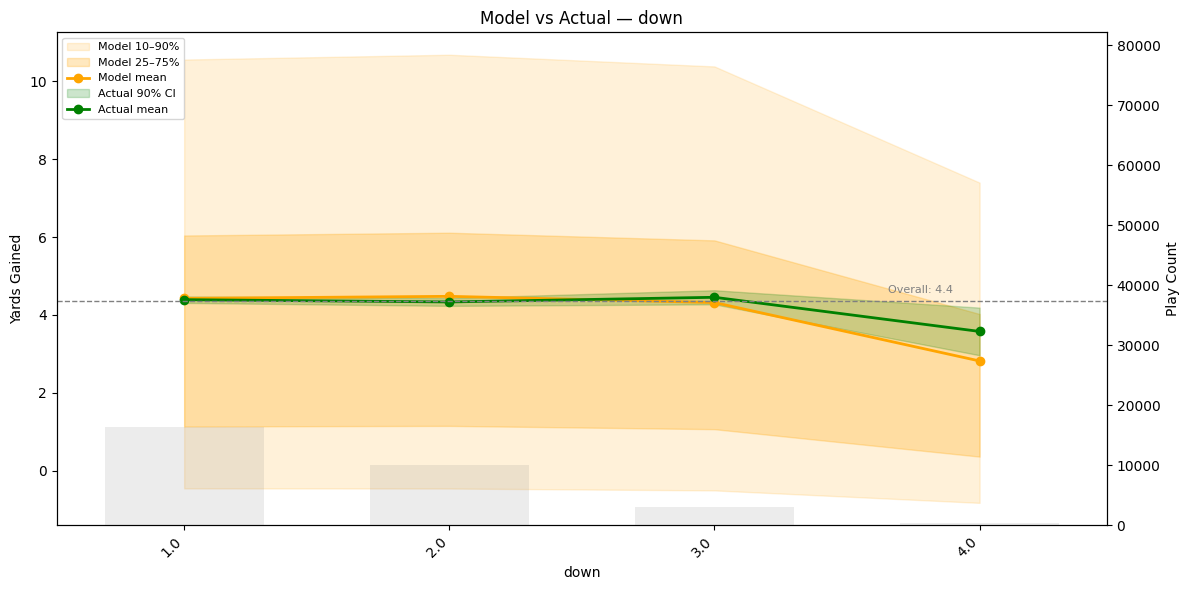

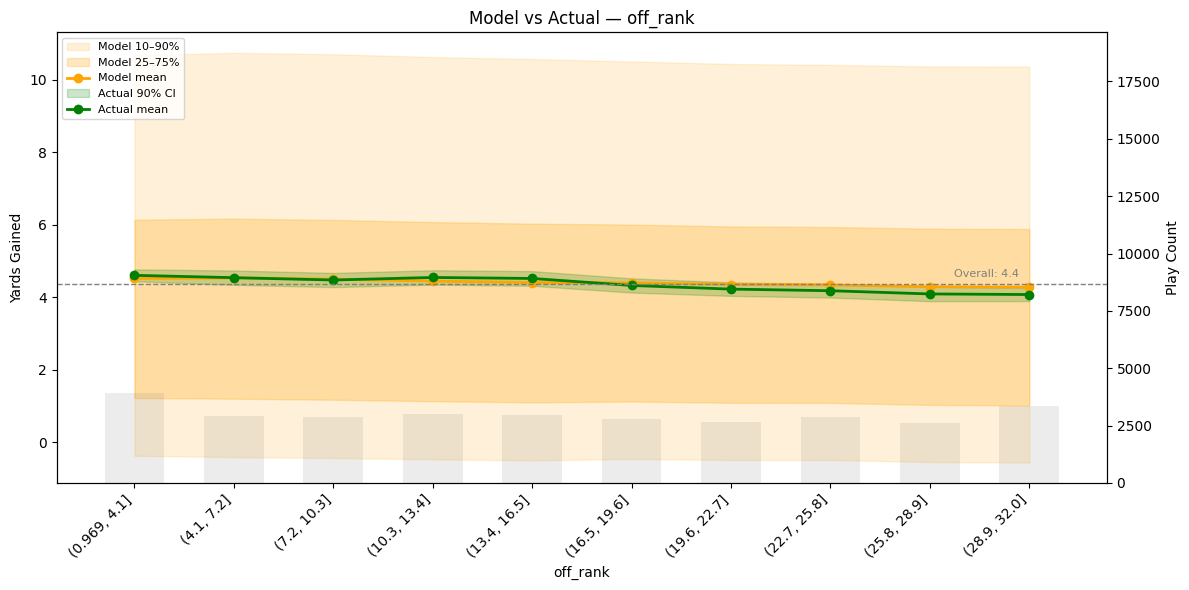

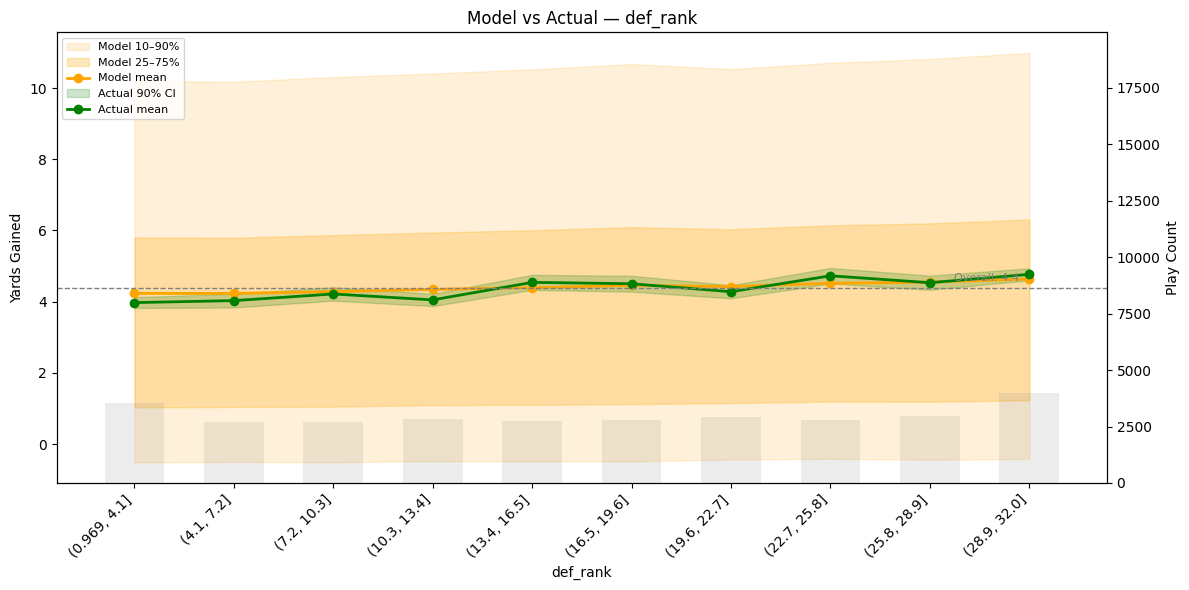

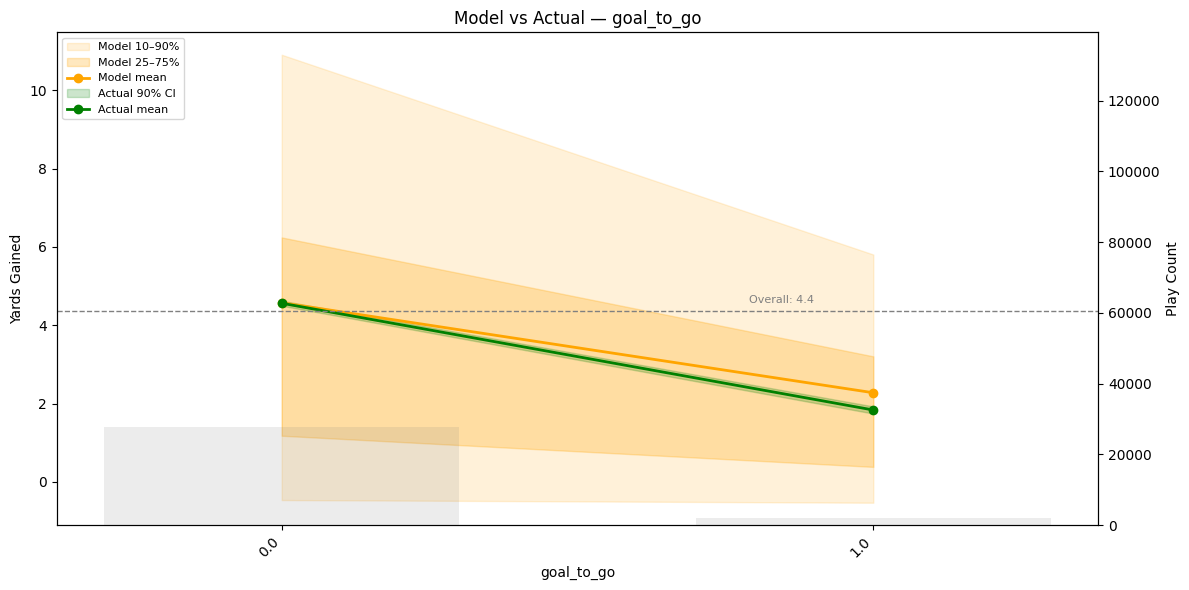

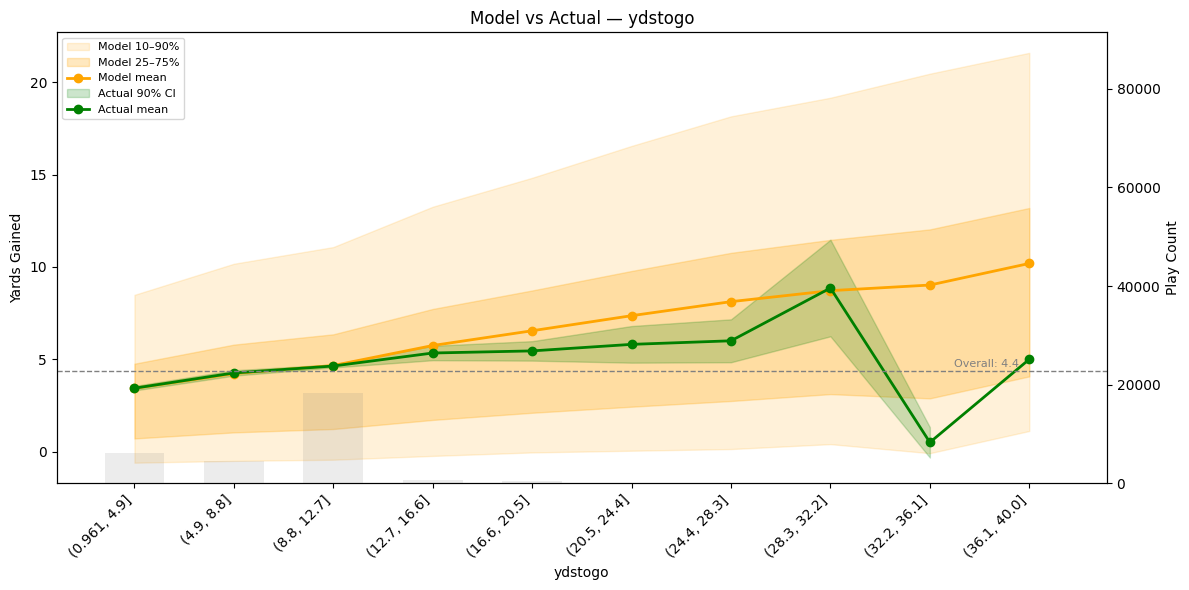

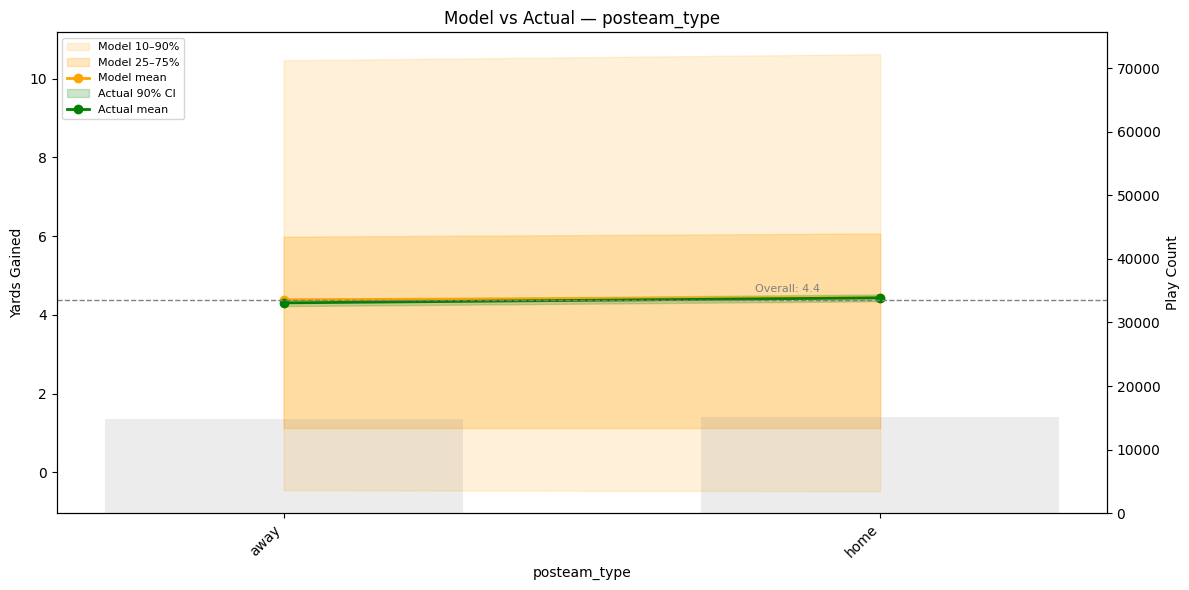

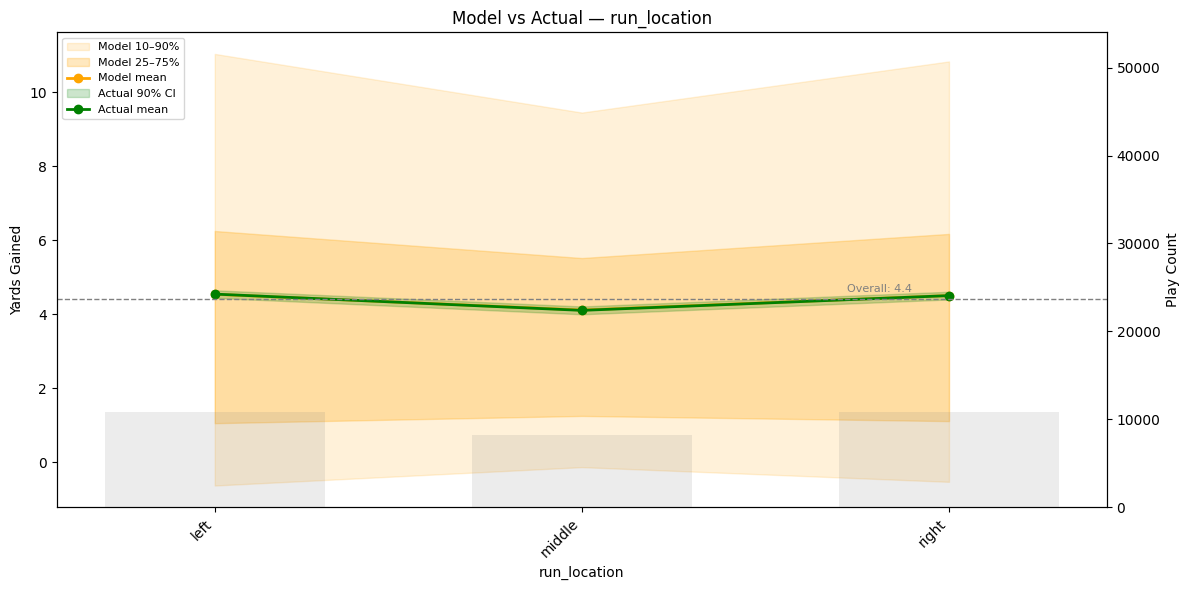

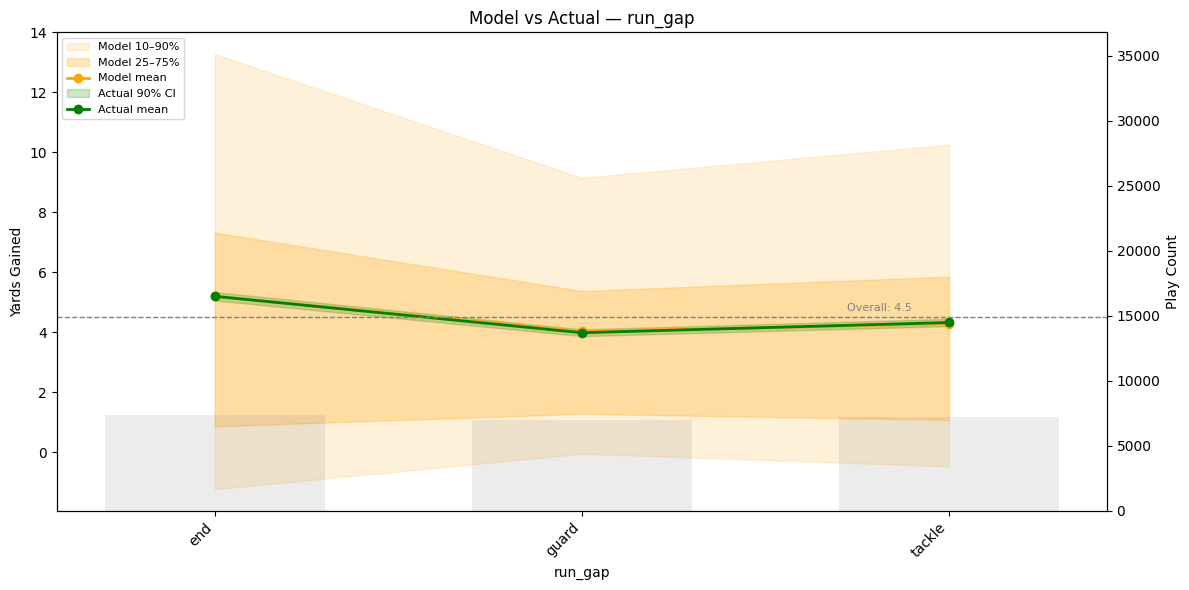

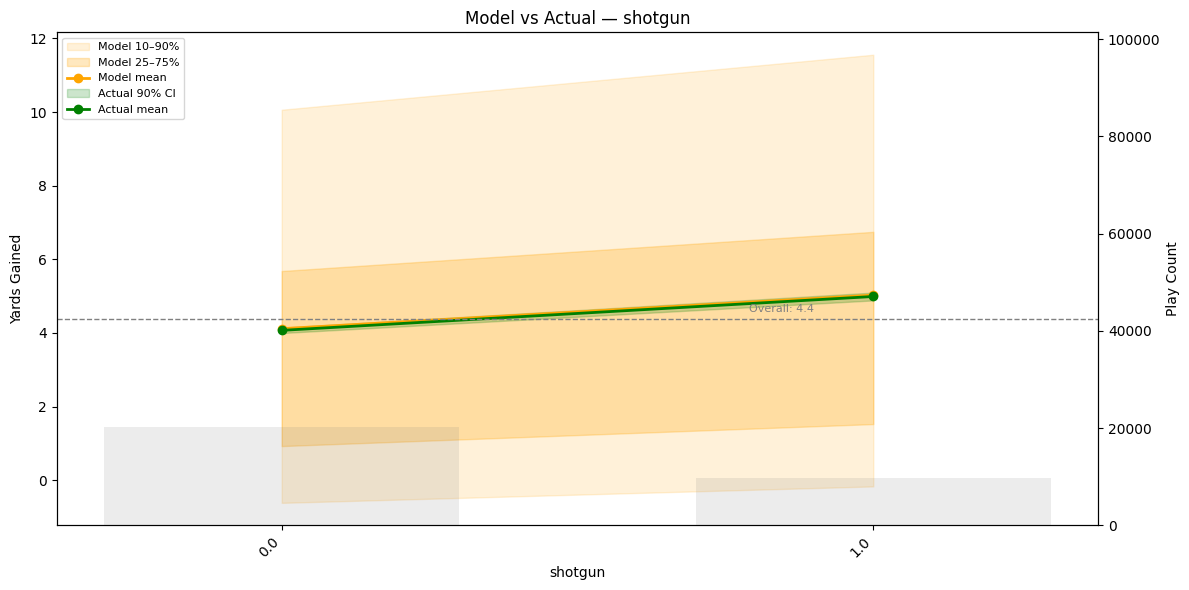

In [147]:
for f in model['features']:
    plot_model_vs_actual(model, test_df, variable=f)

In [148]:
fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_gained",
    features=[],
    dist_name="Johnson SU"
)


──────────────────────────────────────────────────
  Distribution    : Johnson SU
  Test obs        : 29,985
──────────────────────────────────────────────────
  Mean log-lik    : -2.8831
  Mean actual yds : 4.37
  Mean predicted  : 4.32
  MAE             : 3.88 yds
  Calibration 50% : 42.7%  (target 50%)
  Calibration 90% : 89.5%  (target 90%)
  KS stat (PIT)   : 0.0708  p=0.0000
  CRPS            : 2.7732  (lower is better)
──────────────────────────────────────────────────



{'dist': <scipy.stats._continuous_distns.johnsonsu_gen at 0x233a2bc6cf0>,
 'dist_name': 'Johnson SU',
 'beta': array([-3.72979311e-07,  6.27555076e-01,  1.65975793e-06,  9.94424923e-01]),
 'beta_dict': {'loc_intercept': np.float64(0.6275550757885796),
  'log_scale_intercept': np.float64(0.9944249231754867)},
 'shape_params': (np.float64(-0.8339572204613476),
  np.float64(1.0567456874880083)),
 'n_shape': 2,
 'n_features': 1,
 'features': [],
 'yards_col': 'yards_gained'}